<a href="https://colab.research.google.com/github/lsmc-isa/avcad_2026/blob/main/exercise_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análise do Dataset EFIplus_medit

Este notebook realiza uma análise exploratória do dataset `EFIplus_medit`, que contém dados ambientais e de presença/ausência de espécies. As etapas incluem a preparação dos dados, verificação de distribuições de variáveis, transformação de dados para adequação a testes paramétricos, cálculo da riqueza de espécies, detecção de outliers e exploração da relação entre temperatura e riqueza de espécies por país.

### 1. Importação das Bibliotecas Necessárias

Primeiro, importamos todas as bibliotecas Python que serão utilizadas ao longo da análise para manipulação de dados, visualização e detecção de outliers.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import requests

### 2. Upload e Extração do Dataset

Esta célula é responsável pelo upload do arquivo ZIP do dataset e pela sua extração para um diretório temporário. Se você já carregou um arquivo CSV diretamente, a próxima etapa o lerá.

First, let's download and extract the dataset from the provided zip file.

In [1]:
from google.colab import files
import zipfile
import os
import pandas as pd

output_dir = 'EFIplus_medit_data'

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

print("Para extrair os dados do seu computador local, você precisa fazer o upload do arquivo para o Colab.")
print("Por favor, clique em 'Choose Files' para fazer o upload de 'EFIplus_medit.zip' da sua pasta de Downloads.")

# This will open a file picker in the user's browser
uploaded = files.upload()

# Check if file was uploaded
if uploaded:
    # Get the name of the first uploaded file (assuming only one file is uploaded at a time)
    uploaded_file_name = list(uploaded.keys())[0]
    zip_file_path = f'/content/{uploaded_file_name}' # The uploaded file will be in /content/

    print(f"Upload de '{uploaded_file_name}' realizado com sucesso.")
    print(f"Tentando descompactar '{zip_file_path}'...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)
        print("Extração completa!")
    except zipfile.BadZipFile:
        print(f"Erro: O arquivo enviado '{uploaded_file_name}' não é um arquivo ZIP válido. Por favor, certifique-se de fazer o upload de um arquivo ZIP não corrompido.")
    except Exception as e:
        print(f"Ocorreu um erro inesperado durante a extração: {e}")
else:
    print("Nenhum arquivo foi enviado. Por favor, faça o upload do arquivo 'EFIplus_medit.zip' para continuar.")

Para extrair os dados do seu computador local, você precisa fazer o upload do arquivo para o Colab.
Por favor, clique em 'Choose Files' para fazer o upload de 'EFIplus_medit.zip' da sua pasta de Downloads.


Saving EFIplus_medit[1].csv to EFIplus_medit[1].csv
Upload de 'EFIplus_medit[1].csv' realizado com sucesso.
Tentando descompactar '/content/EFIplus_medit[1].csv'...
Erro: O arquivo enviado 'EFIplus_medit[1].csv' não é um arquivo ZIP válido. Por favor, certifique-se de fazer o upload de um arquivo ZIP não corrompido.


### 3. Carregamento do Arquivo CSV

Após o upload (ou se o arquivo CSV já foi carregado diretamente), esta célula carrega o arquivo `EFIplus_medit[1].csv` em um DataFrame do pandas para iniciar a manipulação e análise dos dados. As primeiras 5 linhas são exibidas para uma inspeção inicial.

In [2]:
csv_file_path = '/content/EFIplus_medit[1].csv'
df = pd.read_csv(csv_file_path, sep=';')

print(f"O arquivo '{os.path.basename(csv_file_path)}' foi carregado com sucesso.")
display(df.head())

O arquivo 'EFIplus_medit[1].csv' foi carregado com sucesso.


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


### 4. Verificação Visual das Variáveis Contínuas

Para a primeira parte da tarefa, vamos inspecionar visualmente as distribuições das variáveis ambientais contínuas especificadas (`Altitude`, `Actual_river_slope`, `Elevation_mean_catch`, `prec_ann_catch`, `temp_ann`, `temp_jan`, `temp_jul`). Isso nos ajudará a determinar se alguma delas exigirá transformação de dados para a aplicação de testes paramétricos.

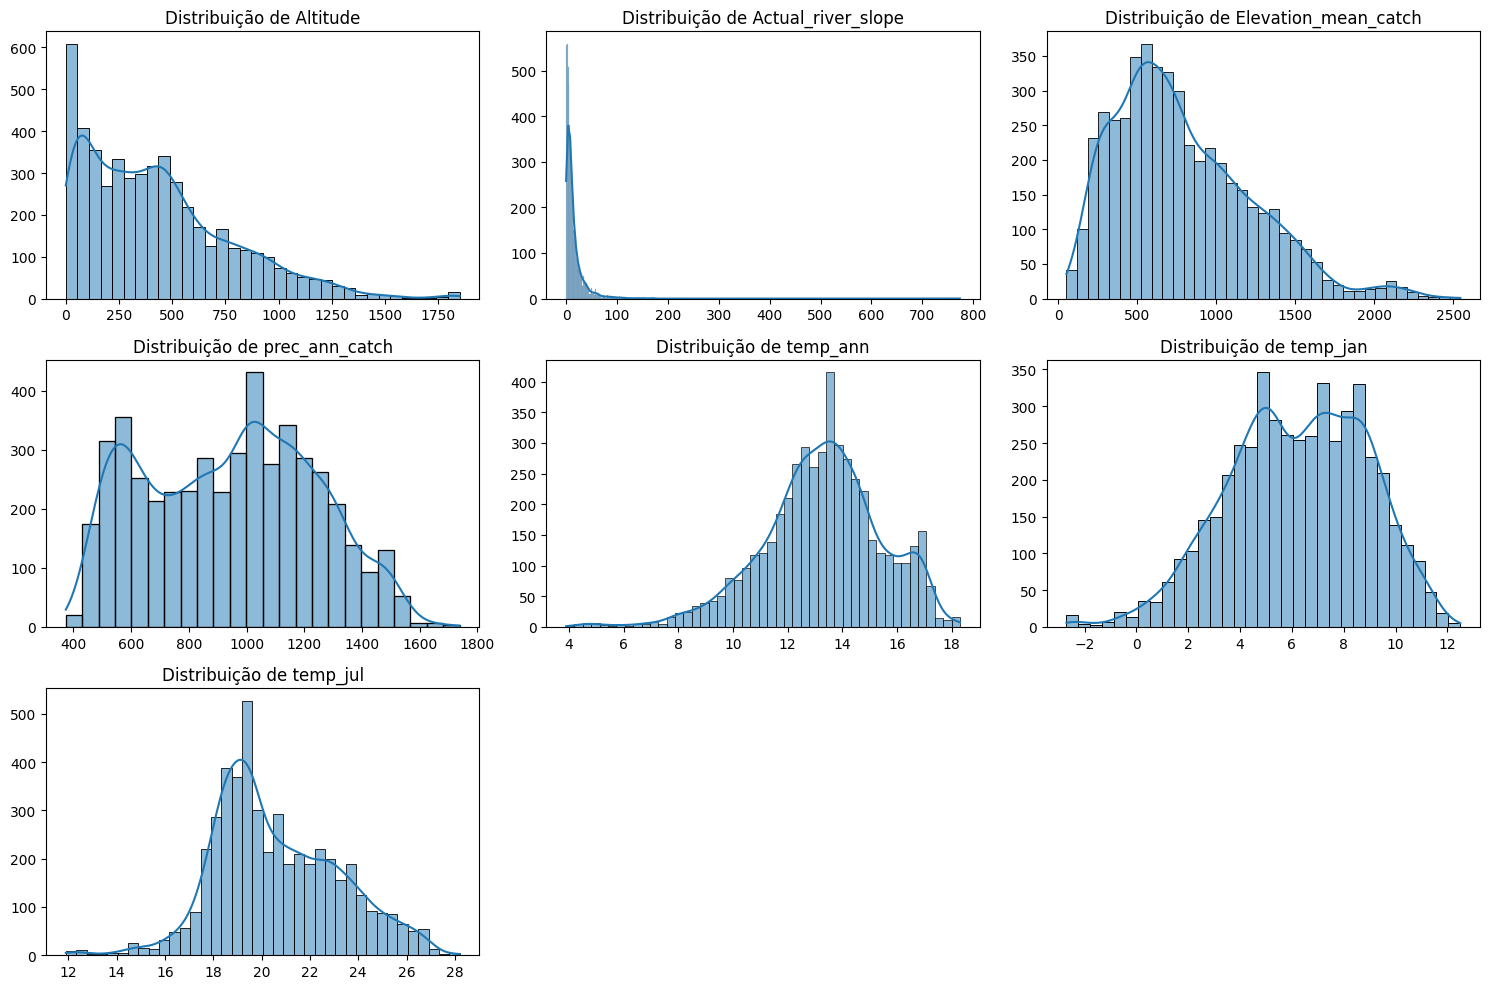

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_vars = [
    'Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
    'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul'
]

plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_vars):
    plt.subplot(3, 3, i + 1) # Arrange in 3 rows, 3 columns
    sns.histplot(df[var].dropna(), kde=True)
    plt.title(f'Distribuição de {var}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### 5. Aplicação de Transformação de Dados e Verificação das Novas Distribuições

Com base nos histogramas anteriores, observamos que algumas variáveis apresentam assimetria à direita. Para adequá-las a testes paramétricos, aplicamos a transformação logarítmica `np.log1p` (log(1+x)), que é útil para dados com valores zero ou positivos e distribuições assimétricas. Em seguida, plotamos novamente as distribuições para verificar a eficácia da transformação.

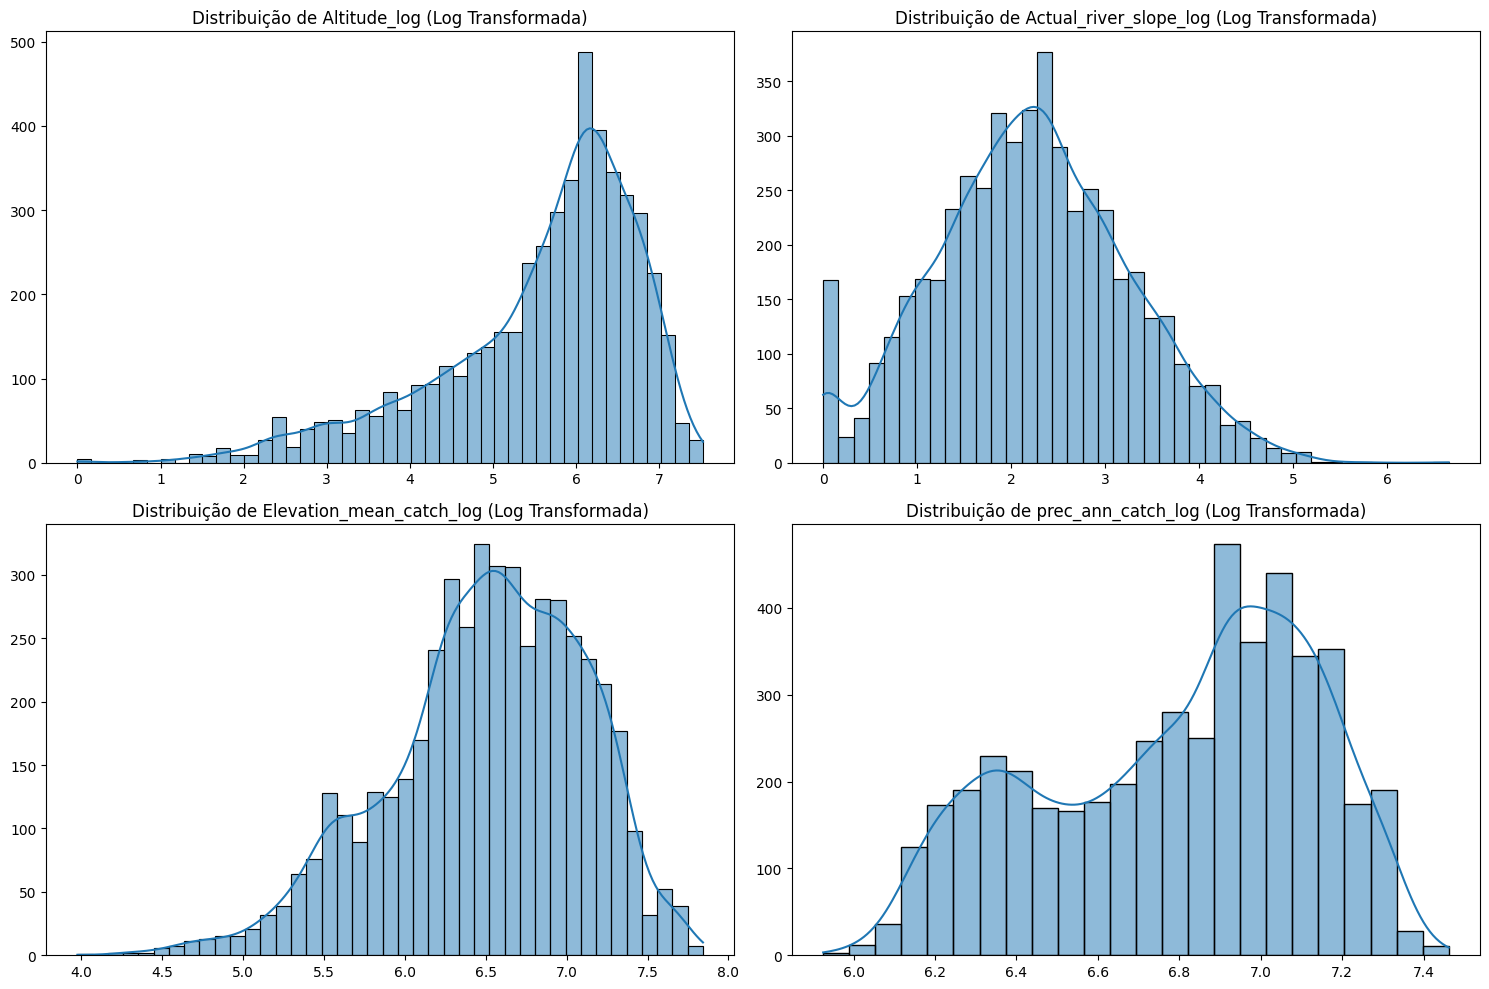

In [7]:
import numpy as np

# Apply log1p transformation to skewed variables
df['Altitude_log'] = np.log1p(df['Altitude'])
df['Actual_river_slope_log'] = np.log1p(df['Actual_river_slope'])
df['Elevation_mean_catch_log'] = np.log1p(df['Elevation_mean_catch'])
df['prec_ann_catch_log'] = np.log1p(df['prec_ann_catch'])

# Plot the new distributions
transformed_vars = [
    'Altitude_log', 'Actual_river_slope_log', 'Elevation_mean_catch_log',
    'prec_ann_catch_log'
]

plt.figure(figsize=(15, 10))
for i, var in enumerate(transformed_vars):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[var].dropna(), kde=True)
    plt.title(f'Distribuição de {var} (Log Transformada)')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### 6. Cálculo da Riqueza de Espécies

Conforme a terceira parte da tarefa, vamos criar uma nova coluna `species_richness` que representa o número total de espécies presentes em cada local de amostragem. Isso é feito somando os valores das colunas correspondentes à presença/ausência de espécies, que começam a partir de 'Abramis brama'.

In [8]:
# Identify the starting column for species data
species_start_index = df.columns.get_loc('Abramis brama')

# Select all columns from the species_start_index to the end
species_columns = df.columns[species_start_index:]

# Calculate species richness (sum of presence/absence for each site)
df['species_richness'] = df[species_columns].sum(axis=1)

print("Coluna 'species_richness' criada com sucesso. Aqui estão as 5 primeiras entradas:")
display(df[['Site_code', 'species_richness']].head())

Coluna 'species_richness' criada com sucesso. Aqui estão as 5 primeiras entradas:


,Site_code,species_richness
0,ES_01_0002,19.112741
1,ES_02_0001,24.645859
2,ES_02_0002,24.211737
3,ES_02_0003,24.987179
4,ES_02_0004,25.245717


### 7. Detecção de Outliers Bivariados

Para a quarta parte da tarefa, vamos verificar a existência de outliers bivariados na relação entre a Temperatura Média Anual (`temp_ann`) e a riqueza de espécies (`species_richness`). Primeiramente, visualizamos a relação com um gráfico de dispersão e, em seguida, aplicamos um modelo de Isolation Forest para detectar e destacar esses outliers.

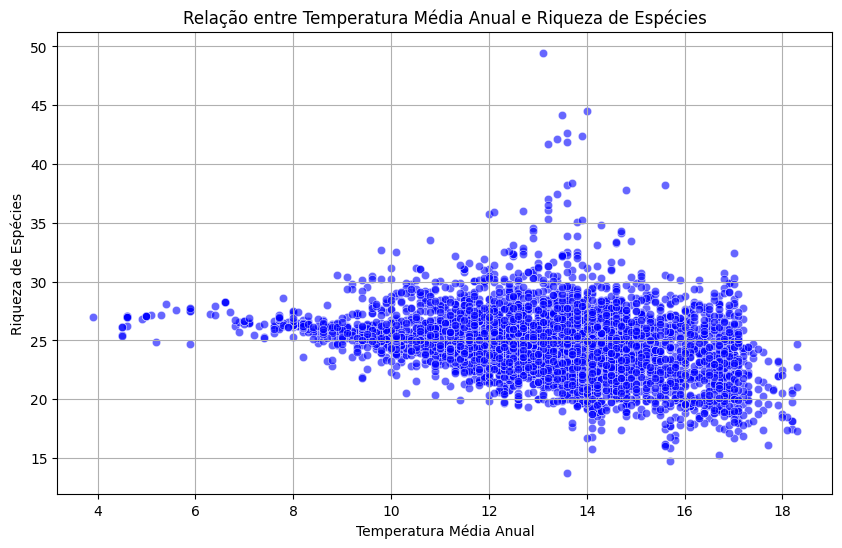

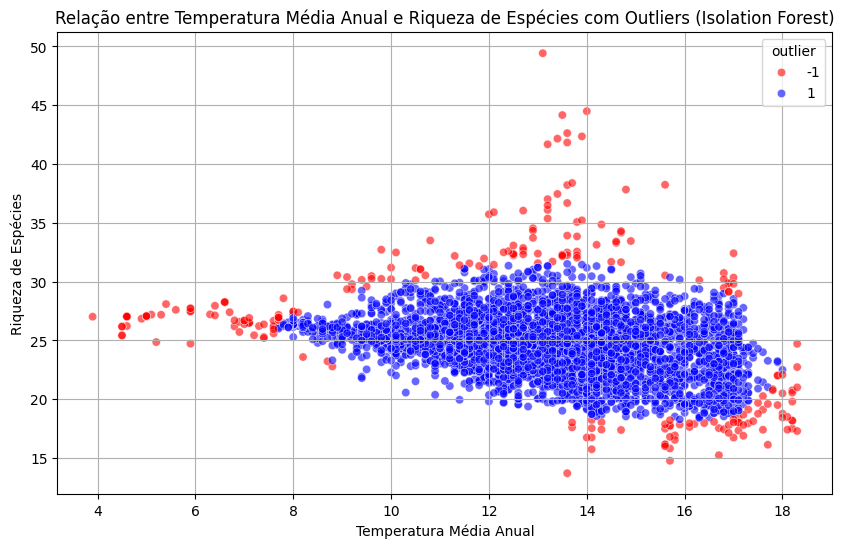

Número de outliers detectados: 241


In [9]:
from sklearn.ensemble import IsolationForest

# Prepare the data for outlier detection
X = df[['temp_ann', 'species_richness']].dropna()

# Plotting the initial relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X, x='temp_ann', y='species_richness', color='blue', alpha=0.6)
plt.title('Relação entre Temperatura Média Anual e Riqueza de Espécies')
plt.xlabel('Temperatura Média Anual')
plt.ylabel('Riqueza de Espécies')
plt.grid(True)
plt.show()

# Apply Isolation Forest for bivariate outlier detection
# contamination is the proportion of outliers in the dataset
model = IsolationForest(random_state=42, contamination=0.05) # Assuming 5% outliers
model.fit(X)
outlier_predictions = model.predict(X)

# Add outlier predictions to the DataFrame for plotting
X_plot = X.copy()
X_plot['outlier'] = outlier_predictions

# Plotting the results with outliers highlighted
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_plot, x='temp_ann', y='species_richness', hue='outlier', palette={1: 'blue', -1: 'red'}, alpha=0.6)
plt.title('Relação entre Temperatura Média Anual e Riqueza de Espécies com Outliers (Isolation Forest)')
plt.xlabel('Temperatura Média Anual')
plt.ylabel('Riqueza de Espécies')
plt.grid(True)
plt.show()

print(f"Número de outliers detectados: {(outlier_predictions == -1).sum()}")

### 8. Exploração da Relação entre Temperatura e Riqueza de Espécies por País

Finalmente, para a quinta parte da tarefa, vamos explorar visualmente se a relação entre a Temperatura Média Anual (`temp_ann`) e a riqueza de espécies (`species_richness`) pode variar entre os diferentes países. Utilizaremos um único gráfico de dispersão, onde cada país será representado por uma cor diferente.

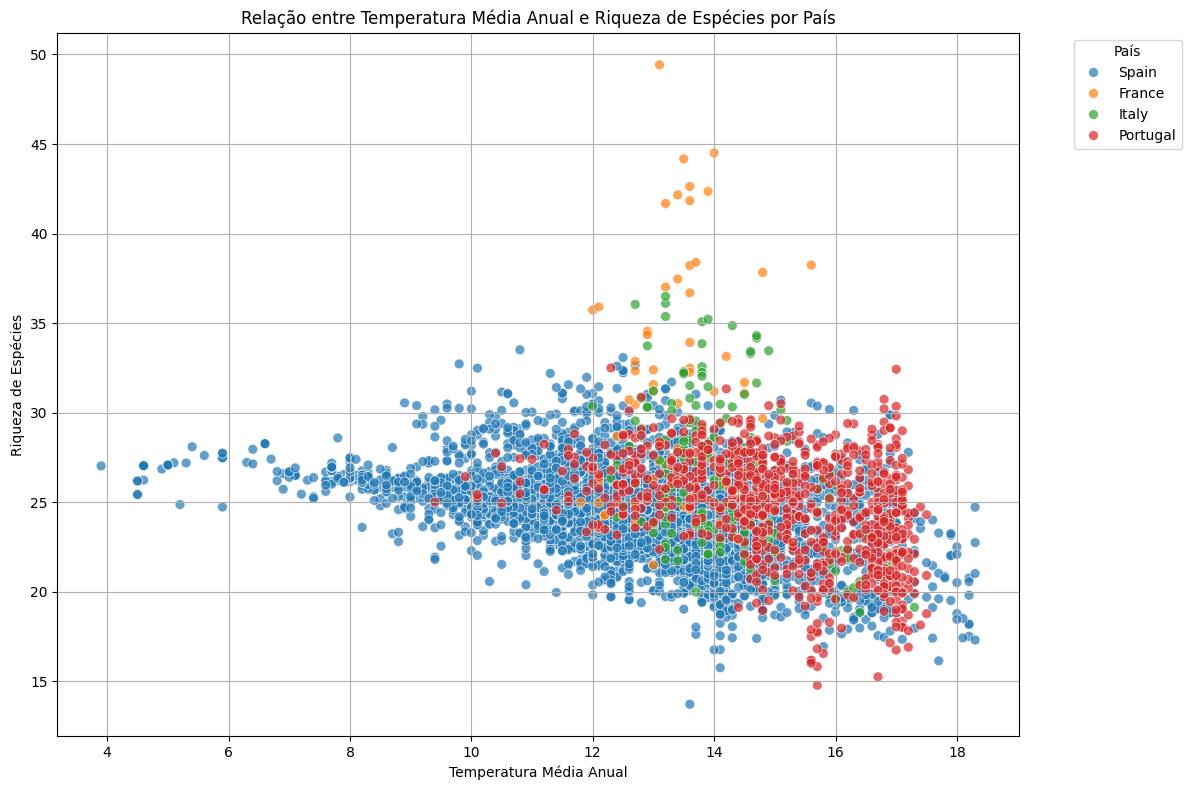

In [10]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='temp_ann', y='species_richness', hue='Country', alpha=0.7, s=50)
plt.title('Relação entre Temperatura Média Anual e Riqueza de Espécies por País')
plt.xlabel('Temperatura Média Anual')
plt.ylabel('Riqueza de Espécies')
plt.grid(True)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()